In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

# from diffSPH.neighborhood import buildNeighborhood
# from diffSPH.operations import SPHOperation
# from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
# from diffSPH.operations import KernelCorrectionScheme
# from diffSPH.kernels import *
# from diffSPH.plotting import visualizeParticles
# from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

In [3]:
particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)
apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' took 2.22 ms  (cached)
Module sphWarpCore.operations.wp_density 6e0e3a3 load on device 'cuda:0' took 2.49 ms  (cached)
Module sphWarpCore.crk.crk_volume 0f6d8bf load on device 'cuda:0' took 1.74 ms  (cached)
Module sphWarpCore.crk.crk_moments 9d838a2 load on device 'cuda:0' took 1.89 ms  (cached)
Module sphWarpCore.crk.crk_density 8012a37 load on device 'cuda:0' took 4.82 ms  (cached)


Module sphWarpCore.operations.wp_gradient 588bd4a load on device 'cuda:0' took 4.29 ms  (cached)
Linear Gradient (WarpSPH):  tensor([[-2.2205e+02,  7.3276e+00],
        [-7.7890e+01,  1.2730e+00],
        [ 6.9288e-01, -6.0351e-02],
        ...,
        [-6.3747e+00, -4.2393e-01],
        [-7.6228e+01, -7.7189e-01],
        [-1.9993e+02,  1.4635e+00]], device='cuda:0')
Mean Absolute Error in X Gradient:  5.070833206176758
Mean Absolute Error in Y Gradient:  0.1944660246372223


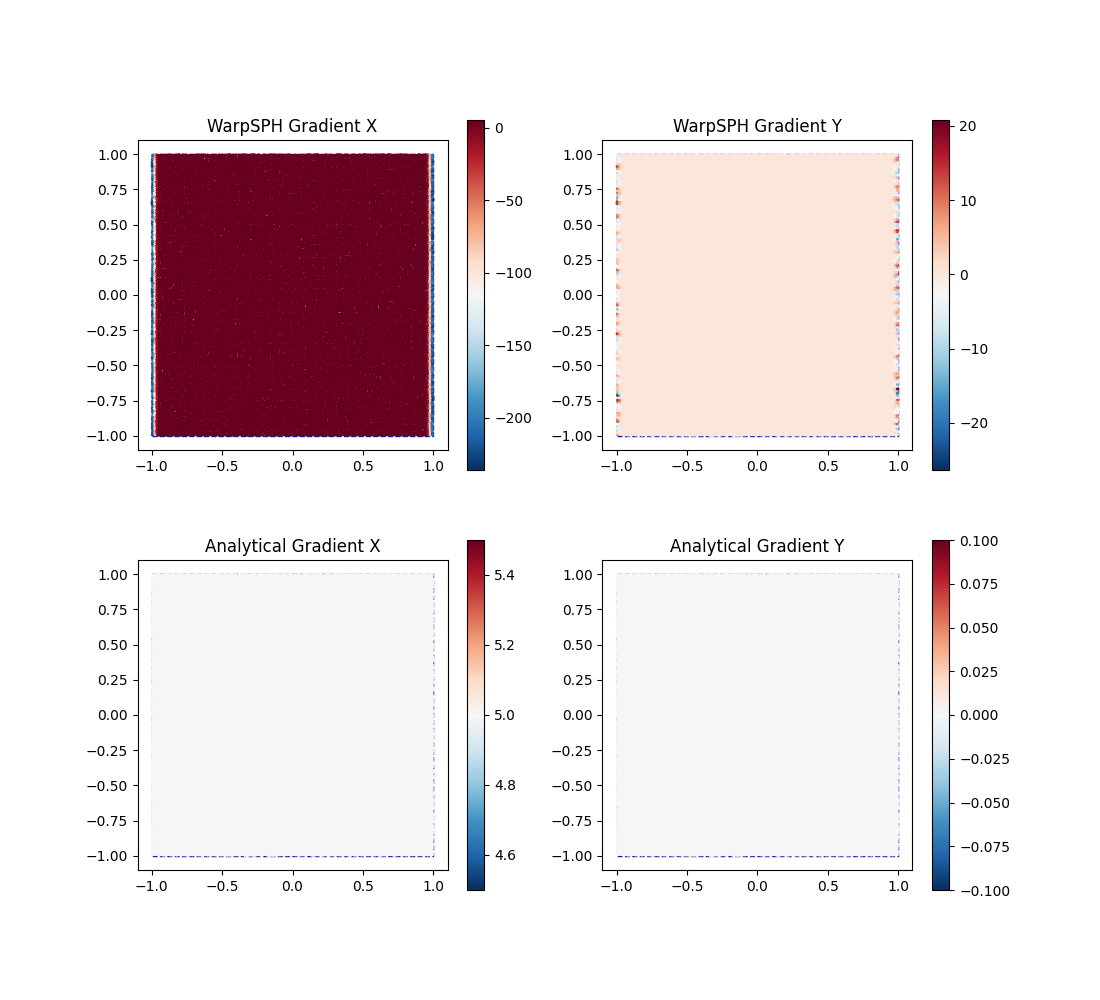

In [4]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

fig, axis = plt.subplots(2,2, figsize = (11,10), squeeze=False)
plotToAxis(fig, axis[0,0], particleState, linear_gradient_warp[:,0], "WarpSPH Gradient X", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[0,1], particleState, linear_gradient_warp[:,1], "WarpSPH Gradient Y", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, f_grad_x, "Analytical Gradient X", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,1], particleState, f_grad_y, "Analytical Gradient Y", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize);

In [5]:
print("Testing Linear Interpolation with WarpSPH...")
print("Input Function: f(x,y) = 5x + 10", 'Min: ', torch.min(f_linear), "Max: ", torch.max(f_linear))
linear_interp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)
print("Linear Interpolation (WarpSPH): ", linear_interp, "Min: ", torch.min(linear_interp), "Max: ", torch.max(linear_interp))

Testing Linear Interpolation with WarpSPH...
Input Function: f(x,y) = 5x + 10 Min:  tensor(5.0188, device='cuda:0') Max:  tensor(14.9819, device='cuda:0')
Module sphWarpCore.operations_grid.wp_interpolate_grid 216d30d load on device 'cuda:0' took 2.44 ms  (cached)
Linear Interpolation (WarpSPH):  tensor([ 8.3042,  5.7277,  5.2504,  ..., 14.8917, 14.1657, 11.7174],
       device='cuda:0') Min:  tensor(4.9728, device='cuda:0') Max:  tensor(15.3598, device='cuda:0')


In [6]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = adjacency,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



Module sphWarpCore.operations.wp_interpolate eea9ac0 load on device 'cuda:0' took 3.44 ms  (cached)


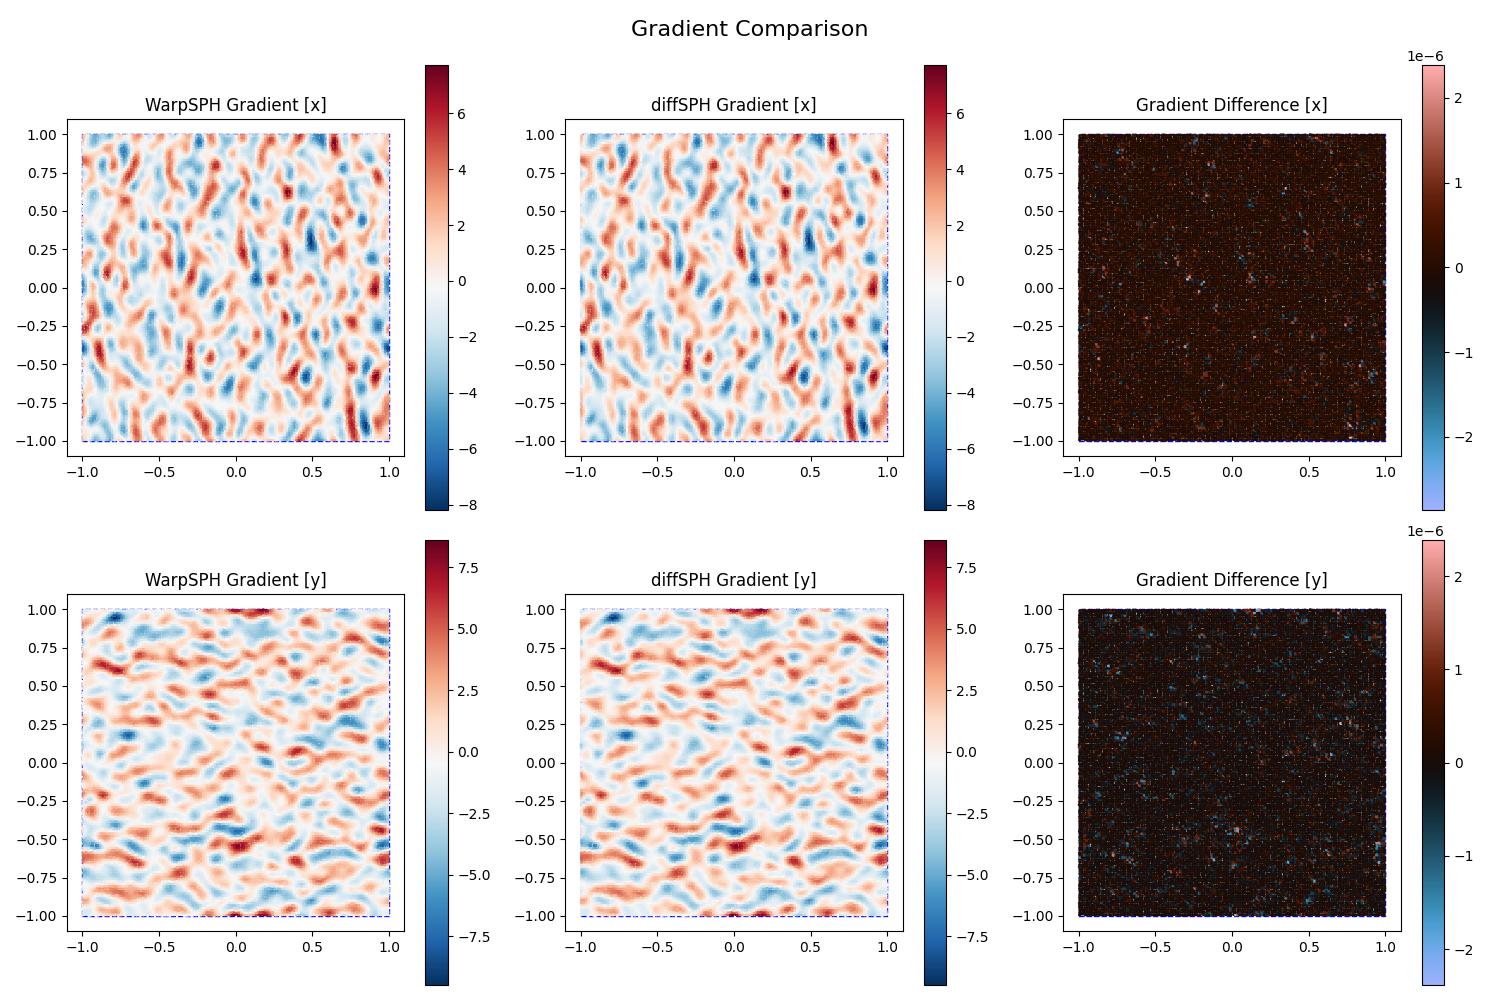

In [7]:
fig, axis = plt.subplots(2,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128


plotToAxis(fig, axis[0,0], particleState, gradient_warp[:,0], "WarpSPH Gradient [x]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, gradient_warp[:,1], "WarpSPH Gradient [y]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

if not warpOnly:
    plotToAxis(fig, axis[0,1], particleState, gradient_diffSPH[:,0], "diffSPH Gradient [x]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
    plotToAxis(fig, axis[1,1], particleState, gradient_diffSPH[:,1], "diffSPH Gradient [y]", 'RdBu_r', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

    diff_x = gradient_warp[:,0] - gradient_diffSPH[:,0]
    diff_y = gradient_warp[:,1] - gradient_diffSPH[:,1]

    plotToAxis(fig, axis[0,2], particleState, diff_x, "Gradient Difference [x]", 'berlin', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
    plotToAxis(fig, axis[1,2], particleState, diff_y, "Gradient Difference [y]", 'berlin', domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

fig.suptitle("Gradient Comparison" if not warpOnly else "WarpSPH Gradient", fontsize = 16)
fig.tight_layout()


In [8]:
from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt
from diffSPH.enums import SupportScheme as DiffSPHSupportScheme, KernelType as DiffSPHKernelType, KernelCorrectionScheme

f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)


In [9]:
gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain
)

gradient_warp_crk = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
    crkState = crkState,
    queryVolumes = apparentVolume,
)


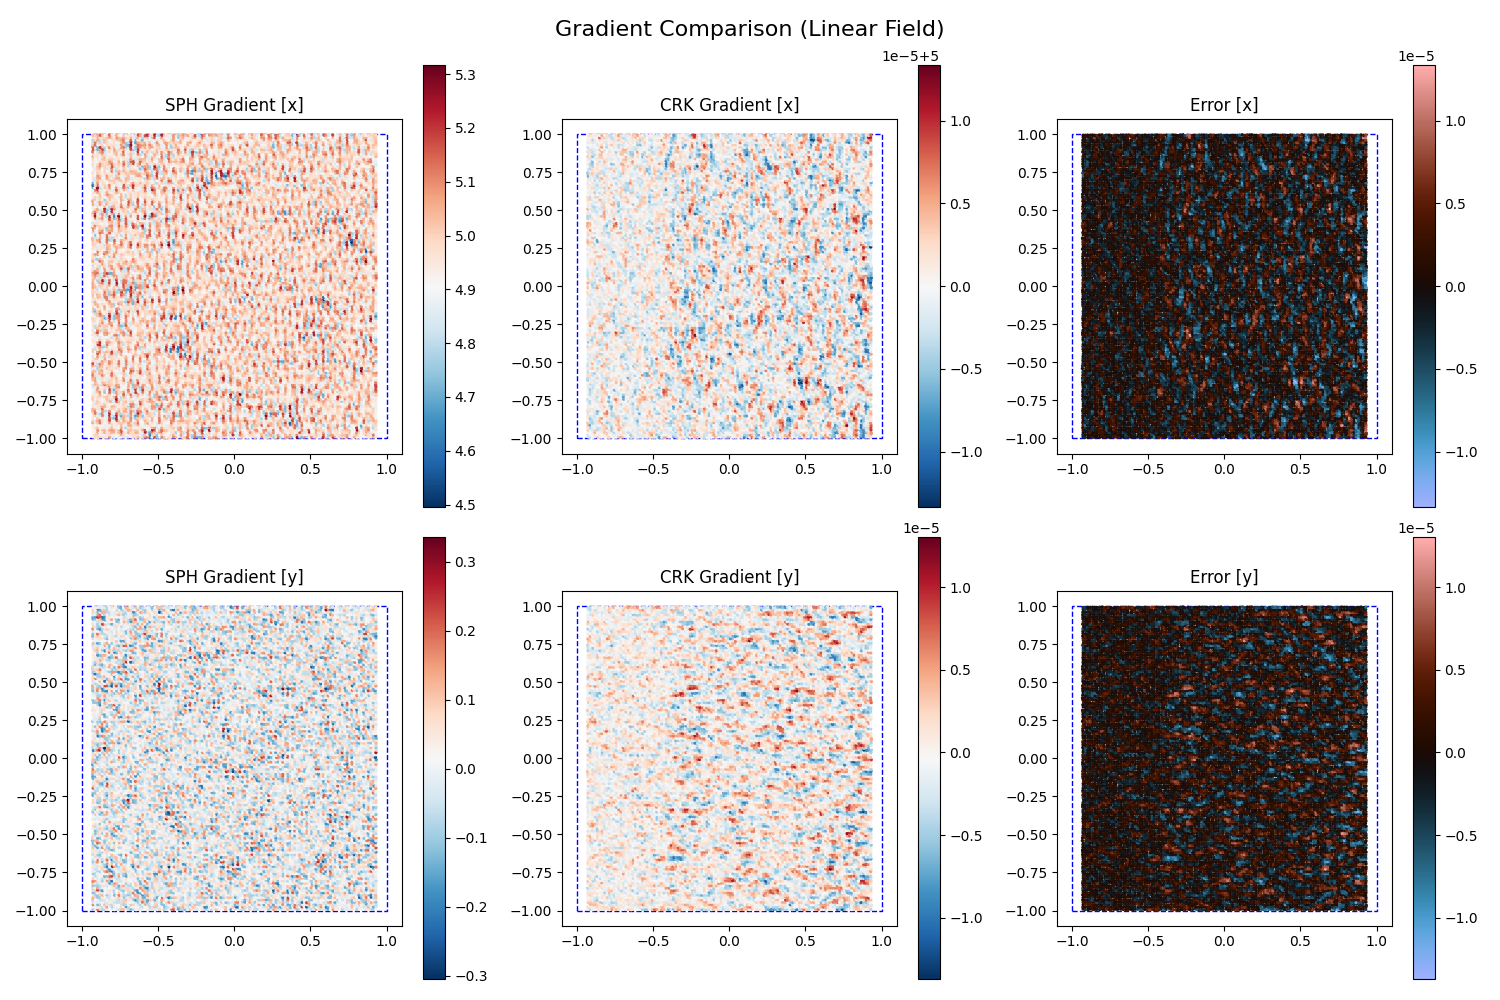

In [10]:
fig, axis = plt.subplots(2, 3, figsize = (15, 10 if not warpOnly else 10), squeeze=False)
mask = torch.logical_and(particleState.positions[:,0] > -1 + dx * 4, particleState.positions[:,0] < 1 - dx * 4)

plotToAxis(fig, axis[0,0], particleState, linear_gradient_warp[:,0], "SPH Gradient [x]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,0], particleState, linear_gradient_warp[:,1], "SPH Gradient [y]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

plotToAxis(fig, axis[0,1], particleState, gradient_warp_crk[:,0], "CRK Gradient [x]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,1], particleState, gradient_warp_crk[:,1], "CRK Gradient [y]", 'RdBu_r', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

err_x = gradient_warp_crk[:,0] - f_grad_x
err_y = gradient_warp_crk[:,1] - f_grad_y

plotToAxis(fig, axis[0,2], particleState, err_x, "Error [x]", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)
plotToAxis(fig, axis[1,2], particleState, err_y, "Error [y]", 'berlin', mask = mask, domain = domain, gridVisualization = gridVisualization, gridResolution = gridResolution, markerSize = markerSize)

fig.suptitle("Gradient Comparison (Linear Field)", fontsize = 16)
fig.tight_layout()

In [11]:

from dataclasses import dataclass


In [12]:
from warpPlot import *

Module sphWarpCore.operations_grid.wp_interpolate_grid de3debc load on device 'cuda:0' took 4.31 ms  (cached)


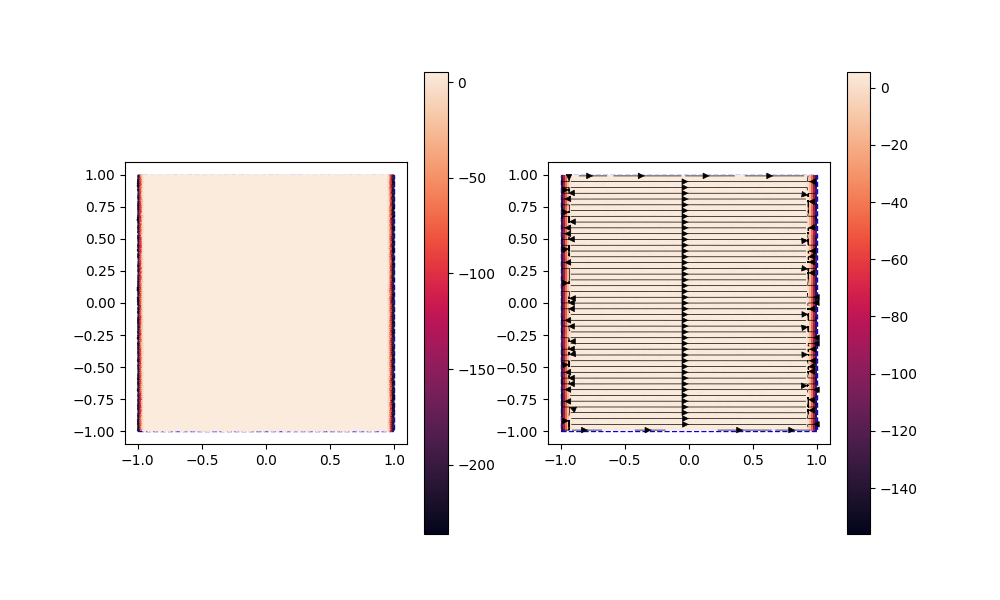

In [13]:
fig, axis = plt.subplots(1,2, figsize=(10,6), squeeze=False)

visualizeParticles(
    fig, axis[0,0],
    particles = particleState,
    quantity = gradient_warp[:,0],
    domain = domain,
    cmap = 'rocket',
    cbar = True,
    markerSize = 2,
);

newState = visualizeParticlesNew(
    fig, axis[0,1],
    particleState = particleState,
    domain = domain,
    quantity = gradient_warp,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        showColorBar = True,
        markerSize = 2,
        midPoint = 'median',
        quantityScaling = PlotScaling.Linear,
        mapping = Mapping.x,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Interpolate,
            gradientMode = GradientScheme.Difference
        ),
        gridVisualization = GridVisualization(
            resolution = 128,
            streamLines = True,
            streamLineOperationLocation=StreamLineLocation.BeforeMapping,
            streamLineOperation=None
        )
    ),
    verbose = False
)

In [14]:
newState = updatePlot(newState, particleState, quantity = gradient_warp, colorMap = ColorMap.mako, midPoint = 0.0, quantityScaling = PlotScaling.Symmetric)

In [15]:
rotated_gradients = torch.vstack([gradient_warp[:,1], -gradient_warp[:,0]]).T
newState = updatePlot(newState, particleState, quantity = rotated_gradients, colorMap = ColorMap.mako, midPoint = 0.0, quantityScaling = PlotScaling.Symmetric)